<h1>PNA Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/geopotential/'

In [4]:
ufs_vars_list = ['phi', 'gh']
era5_var = 'geopotential'
seas5_var = 'z'
lev = 500

In [5]:
ufs_experiments = ['baseline', 'beta.0.1', 'cpc_ics']

In [6]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [7]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [8]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
# The .describe() method prints out a summary of your dataset, or of 1 variable
# seas5_data_reader.describe()
# seas5_data_reader.describe(seas5_var)

<h5>Define time period</h5>

In [11]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (5,)

In [12]:
# For PNA, there are 4 reference locations:
region_1 = {'latmin': 20.0, 'lonmin': 200}
region_2 = {'latmin': 45.0, 'lonmin': 195}
region_3 = {'latmin': 55.0, 'lonmin': 245}
region_4 = {'latmin': 30.0, 'lonmin': 275}

<h5>Get SFS data</h5>

In [13]:
%%capture captured_output
ufs_ds_1 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, lev=lev,
                                  region=region_1, initmonths=initmonths, flatten=True).load()

ufs_ds_2 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, lev=lev,
                                  region=region_2, initmonths=initmonths, flatten=True).load()

ufs_ds_3 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, lev=lev,
                                  region=region_3, initmonths=initmonths, flatten=True).load()

ufs_ds_4 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, lev=lev,
                                  region=region_4, initmonths=initmonths, flatten=True).load()

<h5>Get the corresponding ERA5 data</h5>

In [14]:
# Loading vertical ERA5 data is inherently inefficient.
# Load all lats and lons into memory first, then split into 4 locations.
all_lats = [this_region['latmin'] for this_region in [region_1, region_2, region_3, region_4]]
all_lons = [this_region['lonmin'] for this_region in [region_1, region_2, region_3, region_4]]

In [15]:
# Find nearest lats and lons
all_lats = [era5_data_reader.dataset().sel(lat=this_lat, method='nearest').lat.values.tolist()
            for this_lat in all_lats]

all_lons = [era5_data_reader.dataset().sel(lon=this_lon, method='nearest').lon.values.tolist()
            for this_lon in all_lons]

In [16]:
# Convert to DataArrays (.sel_points() was deprecated, so this is how we do it now.)
all_lats_da = xr.DataArray(all_lats, dims='lat')
all_lons_da = xr.DataArray(all_lons, dims='lon')

In [17]:
# Sel and Load
era5_ds_1234 = era5_data_reader.dataset().sel(lat=all_lats_da,
                                              lon=all_lons_da,
                                              lev=lev,
                                              time=slice(time_range[0], time_range[1]))[[era5_var]].load()  # load

In [18]:
# Split into localities.
era5_ds_1 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[0]], lon=[all_lons[0]]).load()
era5_ds_2 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[1]], lon=[all_lons[1]]).load()
era5_ds_3 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[2]], lon=[all_lons[2]]).load()
era5_ds_4 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[3]], lon=[all_lons[3]]).load()

In [19]:
seas5_ds_1 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_1['latmin'],
                                        lon=region_1['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

seas5_ds_2 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_2['latmin'],
                                        lon=region_2['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

seas5_ds_3 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_3['latmin'],
                                        lon=region_3['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

seas5_ds_4 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_4['latmin'],
                                        lon=region_4['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average


In [20]:
# Because both the seas5 and ufs models have init+lead structure,
# combine seas5 into the ufs dataset as a standalone "member"

# Rename to match ufs
seas5_ds_1 = seas5_ds_1.rename({'z': 'phi'})
seas5_ds_2 = seas5_ds_2.rename({'z': 'phi'})
seas5_ds_3 = seas5_ds_3.rename({'z': 'phi'})
seas5_ds_4 = seas5_ds_4.rename({'z': 'phi'})

# consider ecmwf a 'member'
seas5_ds_1 = seas5_ds_1.assign_coords(member=('member', ['seas5']))
seas5_ds_2 = seas5_ds_2.assign_coords(member=('member', ['seas5']))
seas5_ds_3 = seas5_ds_3.assign_coords(member=('member', ['seas5']))
seas5_ds_4 = seas5_ds_4.assign_coords(member=('member', ['seas5']))

# Concatenate with ufs
ufs_ds_1 = xr.concat([ufs_ds_1, seas5_ds_1], dim='member', coords='minimal', compat='equals')
ufs_ds_2 = xr.concat([ufs_ds_2, seas5_ds_2], dim='member', coords='minimal', compat='equals')
ufs_ds_3 = xr.concat([ufs_ds_3, seas5_ds_3], dim='member', coords='minimal', compat='equals')
ufs_ds_4 = xr.concat([ufs_ds_4, seas5_ds_4], dim='member', coords='minimal', compat='equals')

# Reorder member dimension in the way we want.
ufs_experiments.insert(2, 'seas5')

ufs_ds_1 = ufs_ds_1.reindex(member=ufs_experiments)
ufs_ds_2 = ufs_ds_2.reindex(member=ufs_experiments)
ufs_ds_3 = ufs_ds_3.reindex(member=ufs_experiments)
ufs_ds_4 = ufs_ds_4.reindex(member=ufs_experiments)

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [21]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=True)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=True)
ufs_stats_3 = stats.calc_climatology_anomaly(ufs_ds_3, area_mean=False, use_member_climatology=True)
ufs_stats_4 = stats.calc_climatology_anomaly(ufs_ds_4, area_mean=False, use_member_climatology=True)

In [22]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)
era5_stats_3 = stats.calc_climatology_anomaly(era5_ds_3, area_mean=False)
era5_stats_4 = stats.calc_climatology_anomaly(era5_ds_4, area_mean=False)

Normalize the data. z = (X - mu) / sigma

In [23]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_vars_list[0]], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_vars_list[0]], stats=ufs_stats_2)
ufs_da_3 = stats.normalize(da=ufs_ds_3[ufs_vars_list[0]], stats=ufs_stats_3)
ufs_da_4 = stats.normalize(da=ufs_ds_4[ufs_vars_list[0]], stats=ufs_stats_4)

In [24]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)
era5_da_3 = stats.normalize(da=era5_stats_3['monthly_mean'], stats=era5_stats_3)
era5_da_4 = stats.normalize(da=era5_stats_4['monthly_mean'], stats=era5_stats_4)

<h1>Calculate PNA Index</h1>

In [25]:
ufs_da_1 = ufs_da_1.squeeze(['pressure_level'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['pressure_level'])
ufs_da_3 = ufs_da_3.squeeze(['pressure_level'])
ufs_da_4 = ufs_da_4.squeeze(['pressure_level'])

era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])
era5_da_3 = era5_da_3.squeeze(['lat', 'lon'])
era5_da_4 = era5_da_4.squeeze(['lat', 'lon'])

In [26]:
# Index
ufs_ds_pna = 0.25*(ufs_da_1 - ufs_da_2 + ufs_da_3 - ufs_da_4).to_dataset()
era5_ds_pna = 0.25*(era5_da_1 - era5_da_2 + era5_da_3 - era5_da_4).to_dataset()

<h1>Plot NAO Index</h1>

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

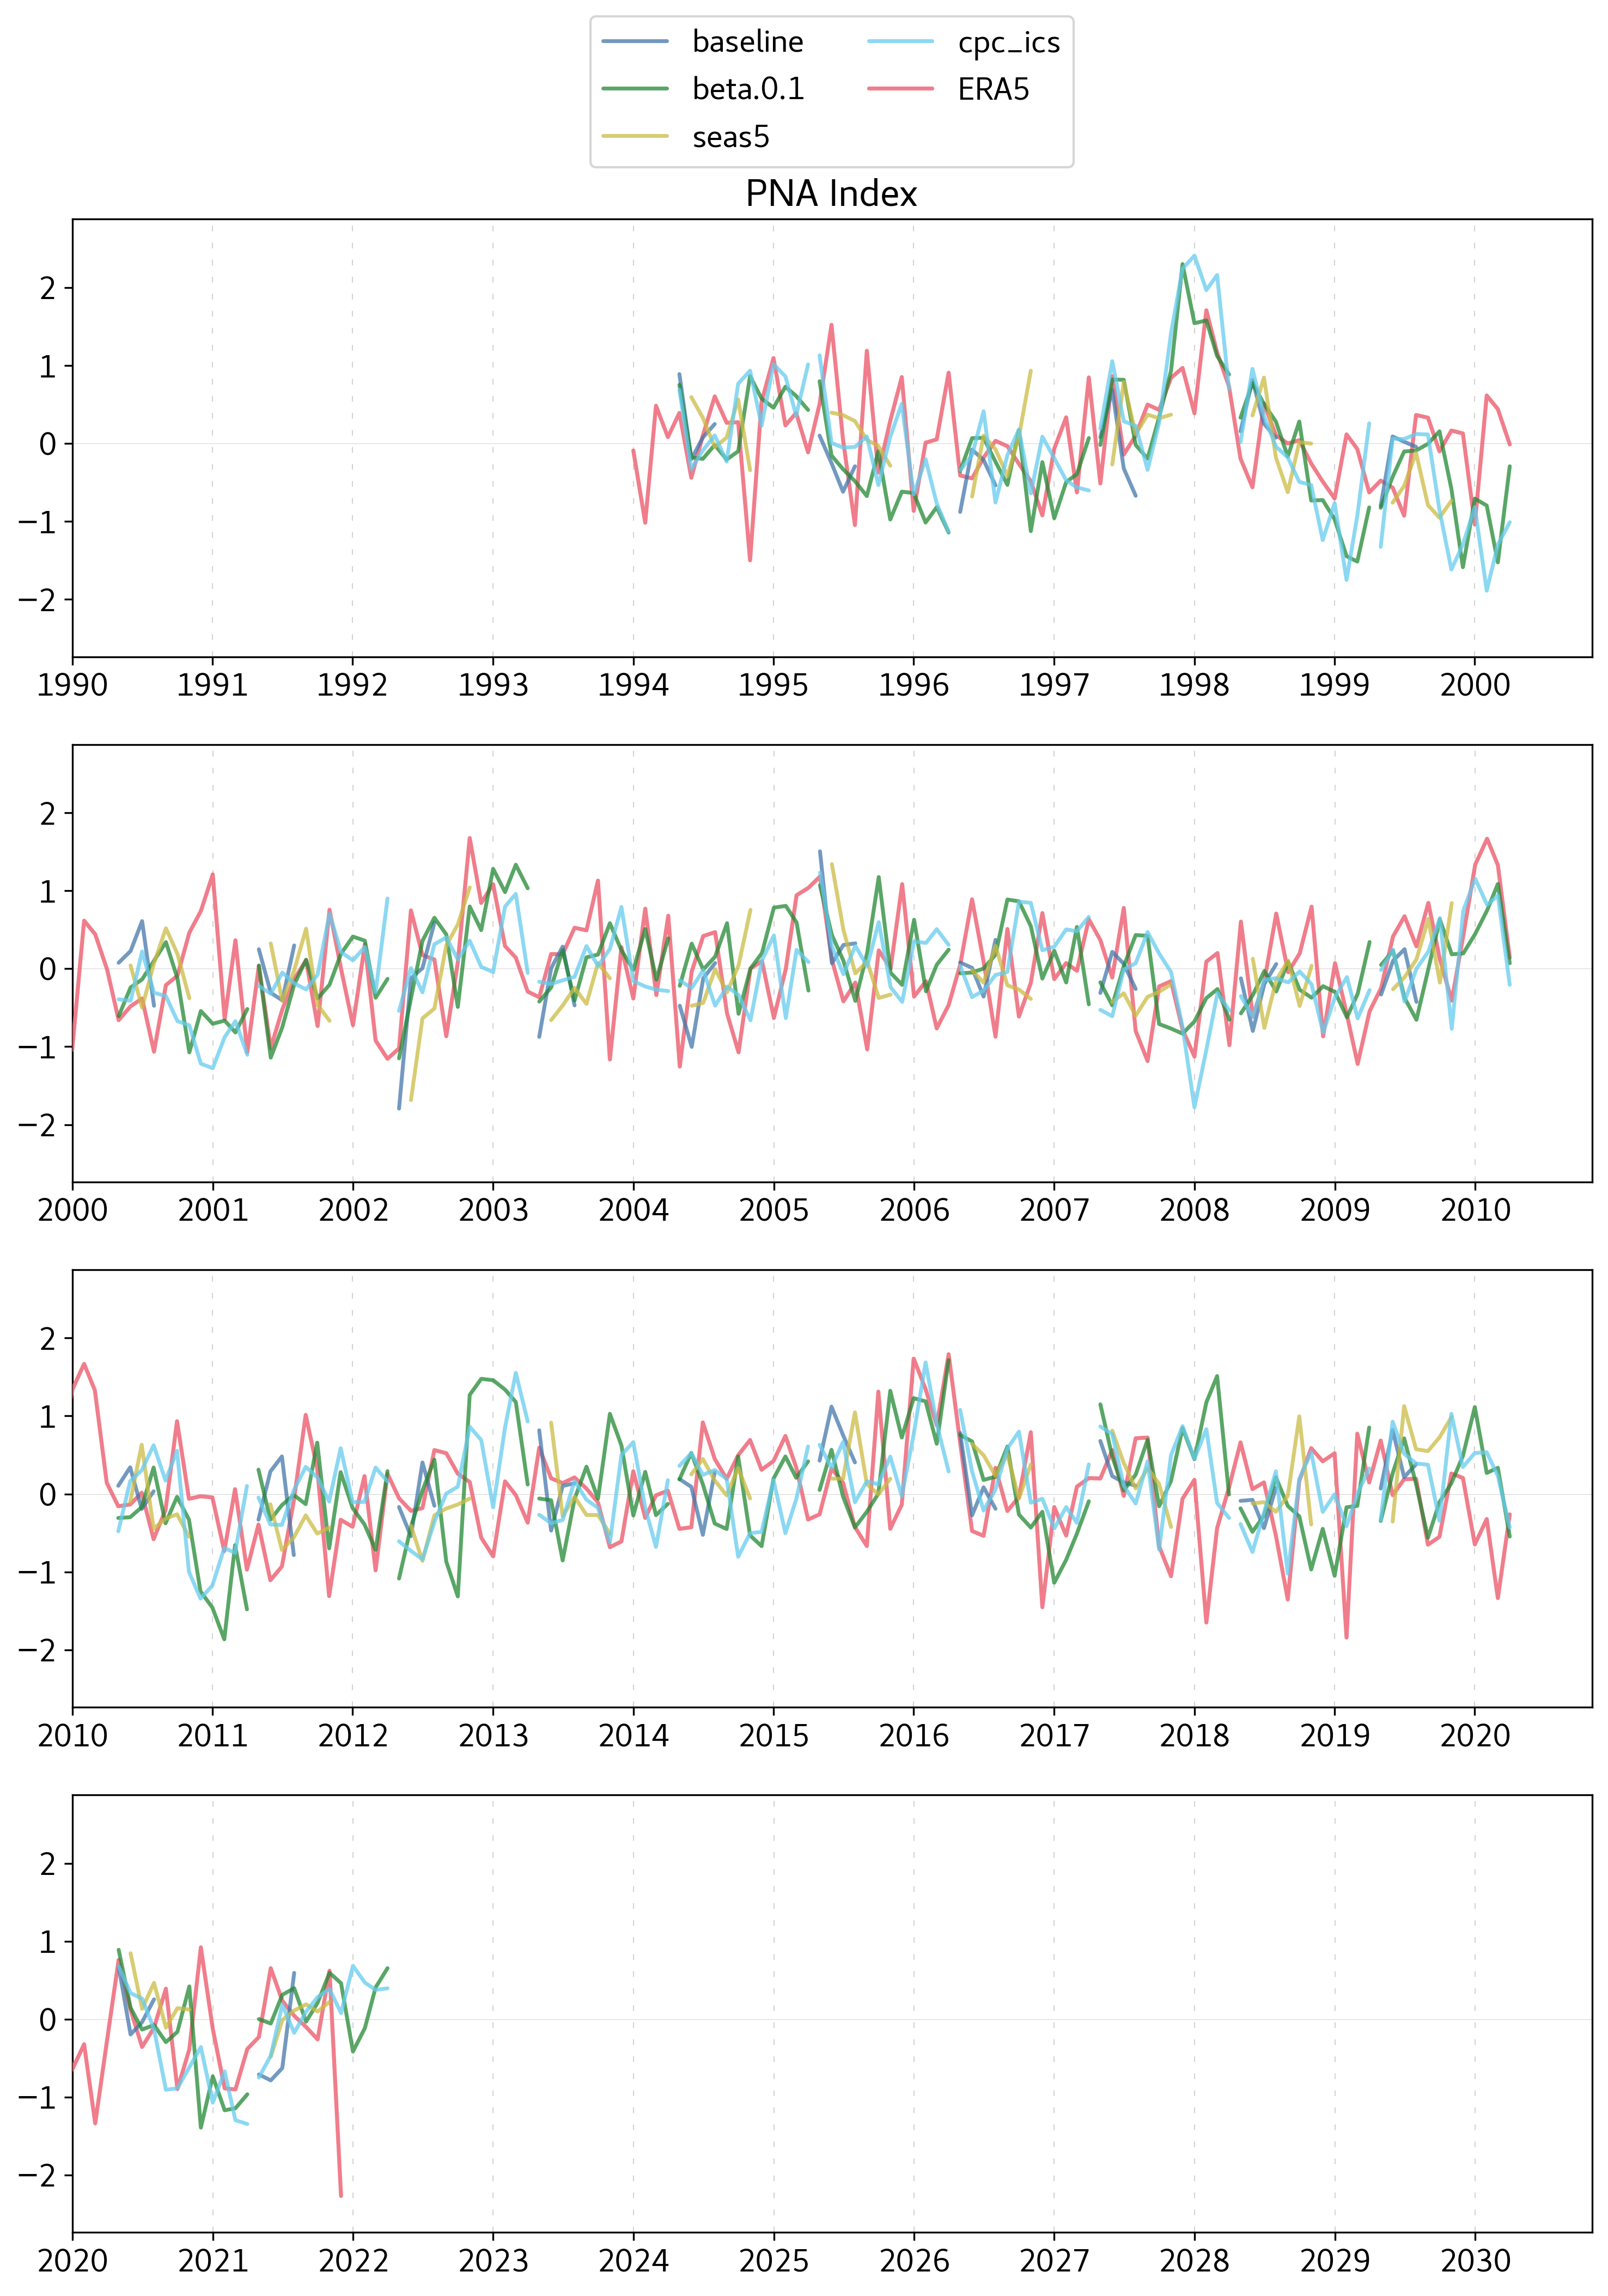

In [27]:
stats.plot_index_spaghetti(ufs_stats={'monthly_mean': ufs_ds_pna[ufs_vars_list[0]]},
                           verif_stats={'monthly_mean': era5_ds_pna[era5_var]},
                           calc_anomaly=False,
                           title=f'PNA Index',
                           verif_label='ERA5',
                           dpi=300)